<a href="https://colab.research.google.com/github/hjiwoong/ML/blob/main/Chapter06_%E1%84%8E%E1%85%A1%E1%84%8B%E1%85%AF%E1%86%AB%E1%84%8E%E1%85%AE%E1%86%A8%E1%84%89%E1%85%A9(PCA).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Mounted at /content/drive


Saving NanumGothic.ttf to NanumGothic.ttf


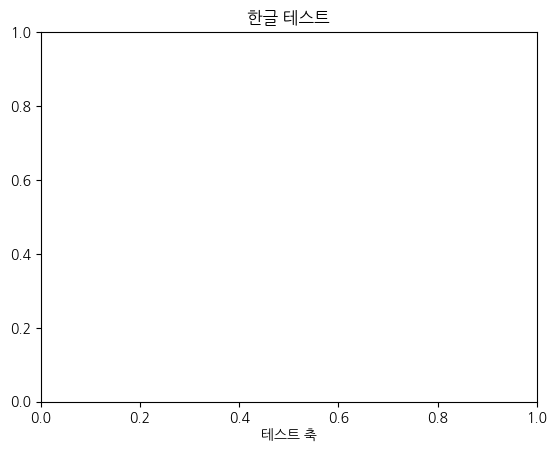

In [1]:
from google.colab import drive, files
drive.mount('/content/drive')

import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import shutil, os

uploaded = files.upload()
font_dst = '/usr/local/share/fonts/NanumGothic.ttf'
os.makedirs('/usr/local/share/fonts', exist_ok=True)
shutil.copy('NanumGothic.ttf', font_dst)

fm.fontManager.ttflist = [
    f for f in fm.fontManager.ttflist
    if '/content/drive' not in f.fname
]

fm.fontManager.addfont(font_dst)
mpl.rc('font', family='NanumGothic')
plt.rcParams['axes.unicode_minus'] = False

fig, ax = plt.subplots()
ax.set_title('한글 테스트')
ax.set_xlabel('테스트 축')
plt.show()

In [25]:
#환경 설정
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import skew

import warnings
warnings.filterwarnings('ignore')
%matplotlib inline

In [35]:
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score

iris = load_iris()
columns = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width']
irisDF = pd.DataFrame(iris.data, columns=columns)
irisDF['target'] = iris.target
print(iris.data.shape)
print('클래스:',iris.target_names)
irisDF.head(3)

(150, 4)
클래스: ['setosa' 'versicolor' 'virginica']


,sepal_length,sepal_width,petal_length,petal_width,target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0


### PCA (주성분 분석)
데이터 분산이 가장 큰 방향으로 새로운 축(주성분)을 만들어 차원 축소, 비지도 학습 - 레이블 없이 수행 가능

In [27]:
#1.표준화
from sklearn.decomposition import PCA

iris_scaled = StandardScaler().fit_transform(irisDF.iloc[:, :-1]) #fit(평균/표준편차 계산) + transform(변환) 동시 수행
print('표준화 후 shape:', iris_scaled.shape)
print('표준화 후 평균 :', np.round(iris_scaled.mean(axis=0),2))
print('표준화 후 표준편차:', np.round(iris_scaled.std(axis=0),2))

표준화 후 shape: (150, 4)
표준화 후 평균 : [-0. -0. -0. -0.]
표준화 후 표준편차: [1. 1. 1. 1.]


In [28]:
#PCA 변환 (4차원 -> 2차원)

#PCA 객체 생성 및 학습
pca = PCA(n_components=2) #상위 2개 주성분(PC1, PC2)으로 축소
pca.fit(iris_scaled) #표준화된 데이터에서 주성분 방향(고유벡터) 학습:
# 내부 동작:
# 1.관계 파악 (공분산 행렬): 변수들끼리 서로 얼마나 닮았는지(상관관계) 확인
# 2.핵심 축 추출 (고유값 분해): 데이터의 분산(정보량)이 가장 큰 방향을 찾아 '주성분'으로 설정
# 3.정보 순서 정렬: 정보량이 많은 순서대로 축을 정렬하여, 원본 데이터를 가장 잘 설명하는 방향을 선택

iris_pca = pca.transform(iris_scaled) #원본 데이터를 주성분 공간으로 투영
print('PCA 변환 후 shape:',iris_pca.shape)

#각 주성분이 원본 데이터 전체 분산의 몇 %를 설명하는지
print('\n분산 설명력 (explained_variance_ratio_):')
print(np.round(pca.explained_variance_ratio_,3)) #PC1 PC2
print(f'\n2개 주성분 누적 설명력: {pca.explained_variance_ratio_.sum():.3f}')
#원본 4개 피처 분산의 약 95.8%를 2개 주성분으로 설명

PCA 변환 후 shape: (150, 2)

분산 설명력 (explained_variance_ratio_):
[0.73  0.229]

2개 주성분 누적 설명력: 0.958


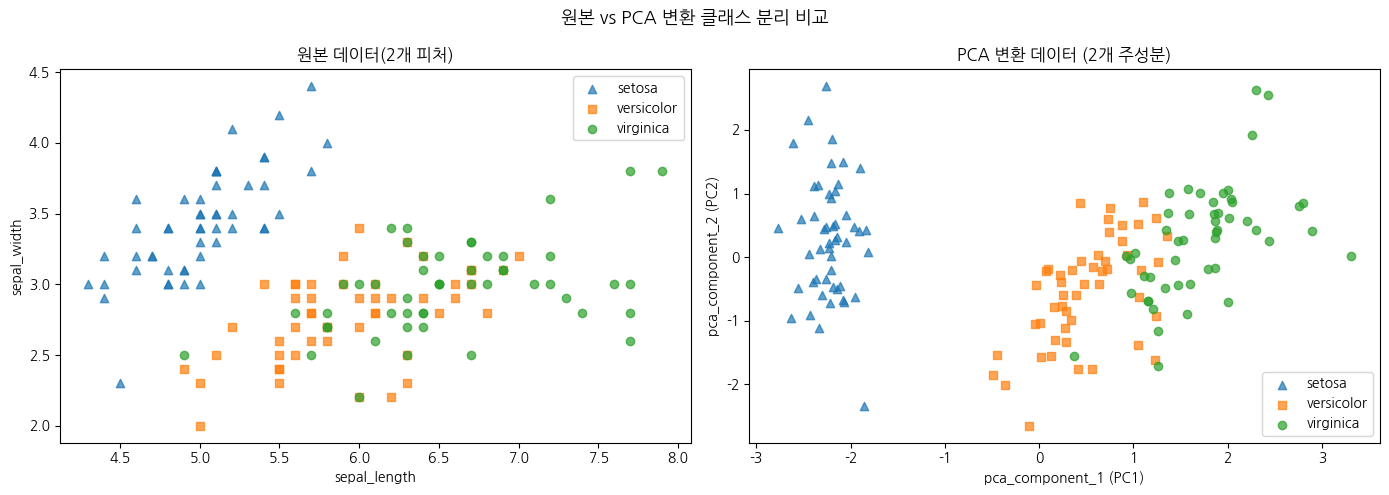

In [29]:
#PCA 변환 전후 산점도 시각화 비교
pca_columns = ['pca_component_1','pca_component_2']
irisDF_pca = pd.DataFrame(iris_pca, columns=pca_columns)
irisDF_pca['target'] = iris.target

fig, axes = plt.subplots(1,2,figsize=(14,5))
markers = ['^','s','o'] #삼각형 setosa, 사각형 versicolor, 원형 virginica
for i, marker in enumerate(markers):
  x = irisDF[irisDF['target'] == i]['sepal_length']
  y = irisDF[irisDF['target'] == i]['sepal_width']
  axes[0].scatter(x,y,marker=marker,label=iris.target_names[i], alpha=0.7)
axes[0].set_title('원본 데이터(2개 피처)')
axes[0].set_xlabel('sepal_length')
axes[0].set_ylabel('sepal_width')
axes[0].legend()

#오른쪽 그래프: PCA 변환 결과 (PC1 vs PC2)
for i, marker in enumerate(markers):
  x = irisDF_pca[irisDF_pca['target'] == i]['pca_component_1']
  y = irisDF_pca[irisDF_pca['target'] == i]['pca_component_2']
  axes[1].scatter(x,y,marker=marker,label=iris.target_names[i], alpha=0.7)
axes[1].set_title('PCA 변환 데이터 (2개 주성분)')
axes[1].set_xlabel('pca_component_1 (PC1)')
axes[1].set_ylabel('pca_component_2 (PC2)')
axes[1].legend()

plt.suptitle('원본 vs PCA 변환 클래스 분리 비교',fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [36]:
#PCA 전후 분류 성능 비교
#차원 축소가 실제 분류 성능에 어떤 영향을 미치는지 정량적으로 확인
rcf = RandomForestClassifier(random_state=156)

#원본 4개 피처로 분류
scores_orig = cross_val_score(
    rcf,
    iris.data,
    iris.target,
    scoring='accuracy',
    cv=3
)
print('원본 데이터 (4개 피처)교차 검증 정확도:', np.round(scores_orig,4))
print('원본 데이터 평균 정확도:{:.4f}'.format(np.mean(scores_orig)))

#PCA 2개 주성분으로 분류
pca_X = irisDF_pca[['pca_component_1','pca_component_2']]
scores_pca = cross_val_score(
    rcf,
    pca_X, #PCA 변환 피처(150,2)
    iris.target,
    scoring='accuracy',
    cv=3
)
print('\nPCA 데이터 (2개 주성분) 교차 검증 정확도:',np.round(scores_pca, 4))
print('PCA 데이터 평균 정확도: {:.4f}'.format(np.mean(scores_pca)))

diff = np.mean(scores_orig) - np.mean(scores_pca)
print(f"\n[결론] 차원 50% 축소(4->2) 시 정확도 차이: {diff:.4f}")

원본 데이터 (4개 피처)교차 검증 정확도: [0.98 0.94 0.96]
원본 데이터 평균 정확도:0.9600

PCA 데이터 (2개 주성분) 교차 검증 정확도: [0.88 0.88 0.88]
PCA 데이터 평균 정확도: 0.8800

[결론] 차원 50% 축소(4->2) 시 정확도 차이: 0.0800


In [38]:
#PCA 실습 - 신용카드 데이터(23개 피처)
#대만 신용카드 채무 불이행 데이터셋 (UCI Machine Learning Repository)
df=pd.read_excel('/content/drive/MyDrive/KWU/ML/Data/pca_credit_card.xls',
                 header=1, sheet_name='Data').iloc[0:,1:]
print(df.shape)
df.head(3)

(30000, 24)


,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
0,20000,2,2,1,24,2,2,-1,-1,-2,...,0,0,0,0,689,0,0,0,0,1
1,120000,2,2,2,26,-1,2,0,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,90000,2,2,2,34,0,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0


In [40]:
#컬럼명 정비 및 피처/레이블 분리
df.rename(columns={'PAY_0':'PAY_1','default payment next month':'default'}, inplace=True) #inplace = df자체를 수정
y_target = df['default'] #0 = 정상 납부(다수), 1 = 채무 불이행(소수 -> 불균형 데이터)
X_features = df.drop('default',axis=1)
print('피처 수:',X_features.shape[1])
print('레이블 분포:')
print(y_target.value_counts())

피처 수: 23
레이블 분포:
default
0    23364
1     6636
Name: count, dtype: int64


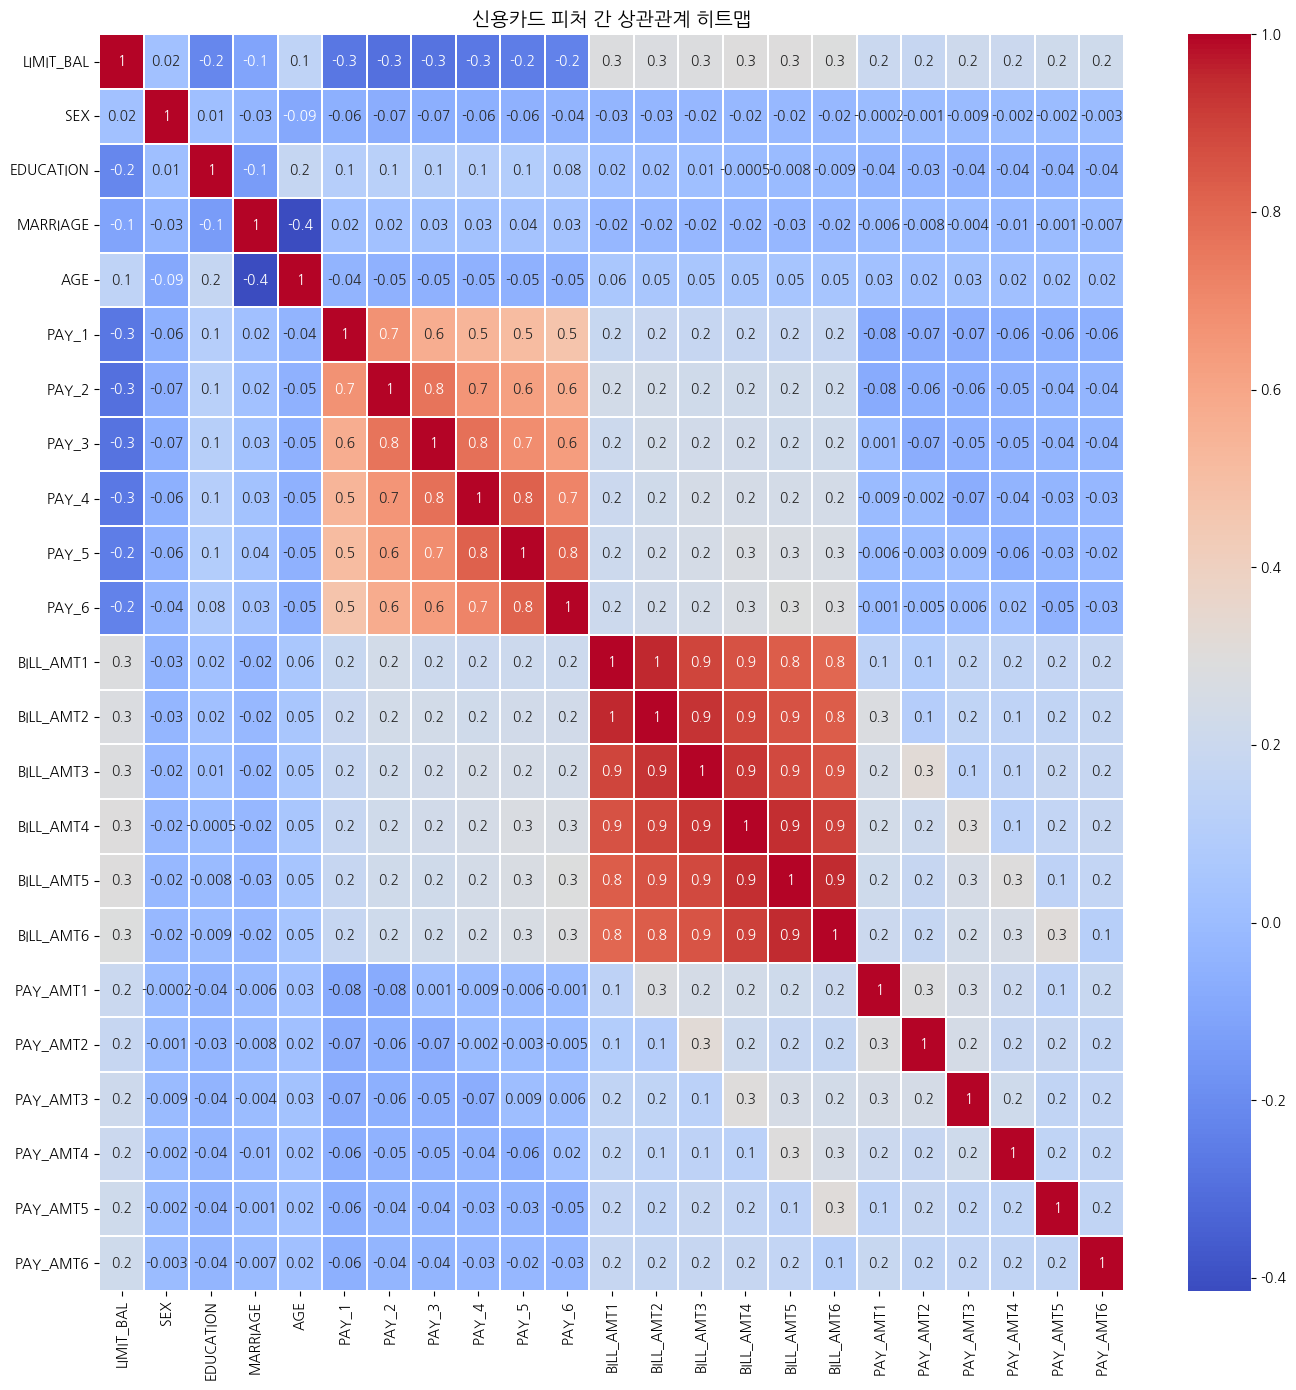

In [43]:
#피처 간 상관 관계 히트맵
corr = X_features.corr() #피처 간 피어슨 상관계수 행렬 계산
plt.figure(figsize=(14,14))
sns.heatmap(corr, annot=True, fmt='.1g', cmap='coolwarm',linewidths=0.3)
plt.title('신용카드 피처 간 상관관계 히트맵',fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()
#상관관계가 높은 피처들 다중공선성문제를, PCA는 이 문제를 해결하며 차원을 축소하는 장점 압축 효과 기대

In [56]:
#BILL_AMT + PAY 12개 피처 PCA 분산 분석 -> 주성분 수(n_components) 결정 탐색
cols_bill = ['BILL_AMT' + str(i) for i in range(1,7)]
cols_pay = ['PAY_' + str(i) for i in range(1,7)]
cols_all = cols_bill + cols_pay
print('대상 컬럼 12개', cols_all)

#12개 피처 표준화
scaler = StandardScaler()
df_cols_scaled = scaler.fit_transform(X_features[cols_all])

#탐색적 PCA:2개 주성분의 설명력 확인
pca_explore = PCA(n_components=2)
pca_explore.fit(df_cols_scaled) #주성분 방향 학습

print('\n2개 주성분 분산 설명력:',np.round(pca_explore.explained_variance_ratio_,3))
print(f"누적 설명력: {pca_explore.explained_variance_ratio_.sum():.3f}")
#누적 설명력이 낮으면 n_components를 늘려서 재확인 2->81%, 6->95%
#6개 주성분만으로 12개 피처 분산의 약95% 설명

대상 컬럼 12개 ['BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_1', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6']

2개 주성분 분산 설명력: [0.529 0.282]
누적 설명력: 0.811


In [58]:
#원본 23개 피처로 랜덤 포레스트 분류
rcf = RandomForestClassifier(
    n_estimators=300,
    random_state=156
)
scores_orig = cross_val_score(
    rcf,
    X_features,
    y_target,
    scoring='accuracy',
    cv=3
)
print('원본 데이터 (23개 피처) 개별 정확도:', np.round(scores_orig,4))
print('원본 데이터 평균 정확도:{:.4f}'.format(np.mean(scores_orig)))

원본 데이터 (23개 피처) 개별 정확도: [0.8083 0.8196 0.8232]
원본 데이터 평균 정확도:0.8170


In [60]:
#전체 23개 피처 -> 6개 주성분 PCA 변환 후 분류
scaler = StandardScaler()
df_scaled = scaler.fit_transform(X_features)

pca_6 = PCA(n_components=6)
df_pca = pca_6.fit_transform(df_scaled)
print('PCA 변환 후 shape:',df_pca.shape)

print('\n6개 주성분 분산 설명력:', np.round(pca_6.explained_variance_ratio_,3))
print("누적 설명력: {:.3f}".format(pca_6.explained_variance_ratio_.sum()))

scores_pca = cross_val_score(
    rcf,
    df_pca, #PCA 변환 후 (N,6)
    y_target,
    scoring='accuracy',
    cv=3
)
print('\nPCA 데이터 (6개 주성분) 개별 정확도:', np.round(scores_pca,4))
print('PCA 데이터 평균 정확도: {:.4f}'.format(np.mean(scores_pca)))

diff = np.mean(scores_orig) - np.mean(scores_pca)
print(f'피처 74% 감소(23->6)에도 정확도 차이: {diff:.4f}')

PCA 변환 후 shape: (30000, 6)

6개 주성분 분산 설명력: [0.284 0.178 0.067 0.064 0.045 0.042]
누적 설명력: 0.680

PCA 데이터 (6개 주성분) 개별 정확도: [0.7912 0.7974 0.802 ]
PCA 데이터 평균 정확도: 0.7969
피처 74% 감소(23->6)에도 정확도 차이: 0.0202


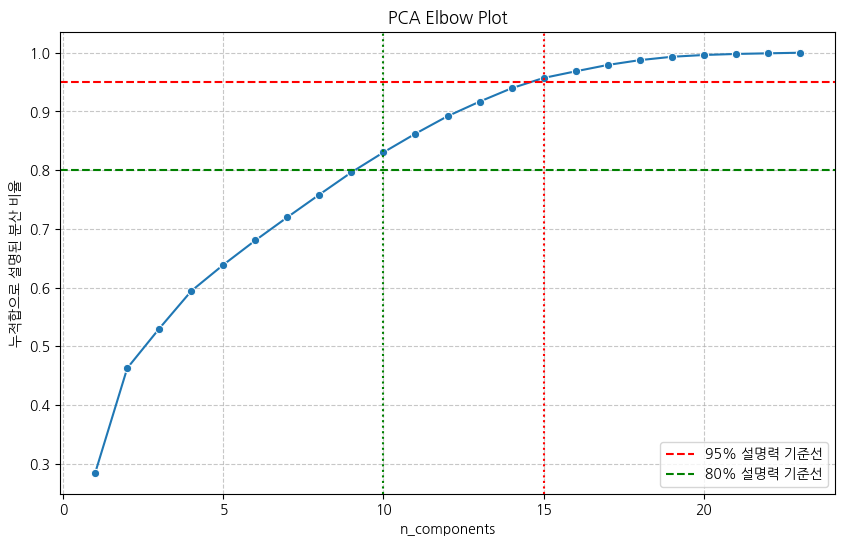

In [61]:
#PCA 누적 설명력 엘보우 플롯 (Elbow Plot) 생성 : n_components 선택을 위한 시각적 분석

#최대 피처 수만큼 PCA 수행하여 각 주성분의 설명력 확인
pca_full = PCA(n_components=X_features.shape[1]) #전체 피처 수 = 23
pca_full.fit(df_scaled)
explained_variance_ratio = pca_full.explained_variance_ratio_ #각 주성분의 설명된 분산 비율
cum_explained_variance = np.cumsum(explained_variance_ratio) #누적합으로 설명된 분산 계산

#엘보우 플롯 시각화
plt.figure(figsize=(10,6))
sns.lineplot(x=range(1,len(cum_explained_variance)+1),y=cum_explained_variance, marker='o')
plt.xlabel('n_components')
plt.ylabel('누적합으로 설명된 분산 비율')
plt.title('PCA Elbow Plot')
plt.grid(True, linestyle='--', alpha=0.7)
plt.axhline(y=0.95, color='r', linestyle='--', label='95% 설명력 기준선')
plt.axhline(y=0.80, color='g', linestyle='--', label='80% 설명력 기준선')
plt.legend()

#엘보우 지점 추정, 80% ,95% 이상 설명하는 최소 주성분 수 찾기
num_components_80 = np.where(cum_explained_variance >= 0.8)[0][0] + 1
num_components_95 = np.where(cum_explained_variance >= 0.95)[0][0] + 1

plt.axvline(x=num_components_80, color='g',linestyle=':', label=f'{num_components_80} 80%이상 설명하는 최소 주성분 수')
plt.axvline(x=num_components_95, color='r',linestyle=':', label=f'{num_components_95} 95%이상 설명하는 최소 주성분 수')
plt.show()

In [63]:
cum_explained_variance

array([0.28448215, 0.46267032, 0.53010339, 0.59411493, 0.63869049,
       0.68030786, 0.71976821, 0.75836022, 0.79624063, 0.83028105,
       0.8621414 , 0.89182928, 0.91665313, 0.93945269, 0.95700228,
       0.96830172, 0.97913339, 0.98733735, 0.99306718, 0.99611743,
       0.99789068, 0.99899047, 1.        ])

In [65]:
np.where(cum_explained_variance >= 0.8)

(array([ 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22]),)

### LDA (선형 판별 분석)
- 분류 문제에서 PCA보다 강력
- PCA: 분산이 가장 큰 방향 탐색 (비지도 학습) -> 정보 보존 목적
- LDA: 클래스 간 분리를 최대화하는 방향 탐색 (지도 학습) -> 분류 목적

In [67]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

#표준화
iris_scaled = StandardScaler().fit_transform(iris.data)

#LDA 변환
lda = LinearDiscriminantAnalysis(n_components=2) #n_components 최댓값 = 클래스 수 -1
lda.fit(iris_scaled, iris.target) #(지도 학습)
iris_lda = lda.transform(iris_scaled)

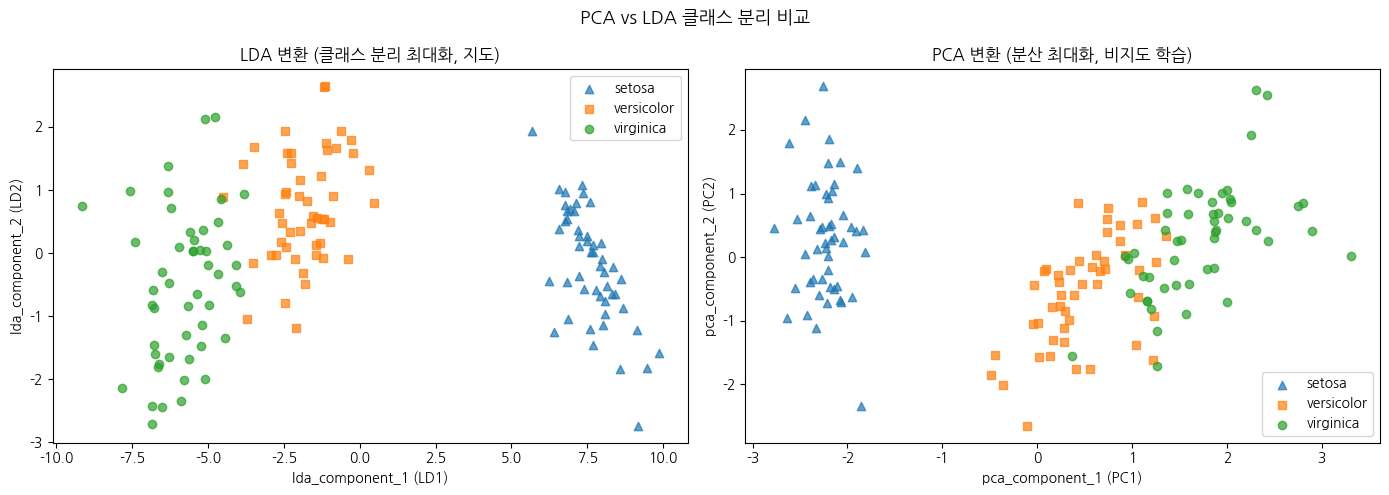

In [71]:
#LDA vs PCA 변환 결과 시각화 비교
lda_columns = ['lda_component_1','lda_component_2']
irisDF_lda = pd.DataFrame(iris_lda, columns=lda_columns)
irisDF_lda['target'] = iris.target

fig, axes = plt.subplots(1,2,figsize=(14,5))
#왼쪽: LDA 결과
for i, marker in enumerate(markers):
  x = irisDF_lda[irisDF_lda['target'] == i]['lda_component_1']
  y = irisDF_lda[irisDF_lda['target'] == i]['lda_component_2']
  axes[0].scatter(x,y,marker=marker,label=iris.target_names[i], alpha=0.7)
axes[0].set_title('LDA 변환 (클래스 분리 최대화, 지도)')
axes[0].set_xlabel('lda_component_1 (LD1)')
axes[0].set_ylabel('lda_component_2 (LD2)')
axes[0].legend()

#오른쪽: PCA 결과
for i, marker in enumerate(markers):
  x = irisDF_pca[irisDF_pca['target'] == i]['pca_component_1']
  y = irisDF_pca[irisDF_pca['target'] == i]['pca_component_2']
  axes[1].scatter(x,y,marker=marker,label=iris.target_names[i], alpha=0.7)
axes[1].set_title('PCA 변환 (분산 최대화, 비지도 학습)')
axes[1].set_xlabel('pca_component_1 (PC1)')
axes[1].set_ylabel('pca_component_2 (PC2)')
axes[1].legend()

plt.suptitle('PCA vs LDA 클래스 분리 비교',fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

#LDA는 분류 목적에 최적화 -> 클래스가 더 명확히 분리됨

In [73]:
#LDA vs PCA 분류 성능 최종 비교
rcf = RandomForestClassifier(random_state=156)
scores_lda = cross_val_score(
    rcf,
    iris_lda, #LDA 변환 후 (150,2)
    iris.target,
    scoring='accuracy',
    cv=3
)
print('LDA 변환 데이터 교차 검증 정확도:',np.round(scores_lda,4))
print('LDA 평균 정확도: {:.4f}'.format(np.mean(scores_lda)))
#원본 데이터 평균 정확도: 0.9600
#PCA 데이터 평균 정확도: 0.7969

LDA 변환 데이터 교차 검증 정확도: [1.   0.9  0.94]
LDA 평균 정확도: 0.9467


### TruncatedSVD
- 표준화 후 TruncatedSVD vs PCA 비교
- 표준화 후에는 두 결과가 동일함

In [75]:
from sklearn.decomposition import TruncatedSVD, PCA

iris_scaled = StandardScaler().fit_transform(iris.data)

tsvd2 = TruncatedSVD(n_components=2)
iris_tsvd_scaled = tsvd2.fit_transform(iris_scaled)

pca2 = PCA(n_components=2)
iris_pca_scaled = pca2.fit_transform(iris_scaled)

print('표준화 후 TruncatedSVD vs PCA 차이:')
print('변환값 차이 (평균):',(iris_pca_scaled - iris_tsvd_scaled).mean())
print('주성분 방향 차이 (평균):',(pca2.components_ - tsvd2.components_).mean())
#값이 거의 0-> 표준화 후 TruncatedSVD = PCA (동일한 알고리즘)

#일반 밀집 행렬 (dense matrix) -> PCA 사용
#희소 행렬 (sparse matrix) -> TruncatedSVD 사용
#예 : 텍스트 TF-IDF (단어 수만 개 × 문서 수만 개, 대부분 0)

표준화 후 TruncatedSVD vs PCA 차이:
변환값 차이 (평균): 2.3387657551351046e-15
주성분 방향 차이 (평균): -1.0408340855860843e-16


### NMF(비음수 행렬 분해)

In [78]:
from sklearn.decomposition import NMF
iris = load_iris()
iris_ftrs = iris.data

#NMF 사용 시 표준화(SrandardScaler) 금지
nmf = NMF(n_components=2) #n_components=2 : 2개의 잠재 요인으로 분해
nmf.fit(iris_ftrs)
iris_nmf = nmf.transform(iris_ftrs)

print('NMF 변환 후 shape:',iris_nmf.shape)

NMF 변환 후 shape: (150, 2)
